In [6]:
import cv2
import os
import matplotlib.pyplot as plt

input_folder = "documents"
output_folder = "output"

os.makedirs(output_folder, exist_ok=True)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))

for filename in os.listdir(input_folder):
    image_path = os.path.join(input_folder, filename)
    image = cv2.imread(image_path)

    if image is None:
        continue

    # Original
    original = image.copy()

    # Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Gaussian Blur
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Edge Detection
    edges = cv2.Canny(blur, 75, 200)

    # Morphological Closing
    morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    # Find Contours
    contours, _ = cv2.findContours(
        morph,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    output = image.copy()
    if contours:
        largest = max(contours, key=cv2.contourArea)

        cv2.drawContours(
            output,
            [largest],
            -1,
            (0,255,0),
            3
        )

    # Save Images
    name = os.path.splitext(filename)[0]
    
    cv2.imwrite(f"{output_folder}/{name}_original.jpg", original)
    cv2.imwrite(f"{output_folder}/{name}_edges.jpg", edges)
    cv2.imwrite(f"{output_folder}/{name}_morphology.jpg", morph)
    cv2.imwrite(f"{output_folder}/{name}_boundary.jpg", output)

print("All images processed successfully!")

All images processed successfully!


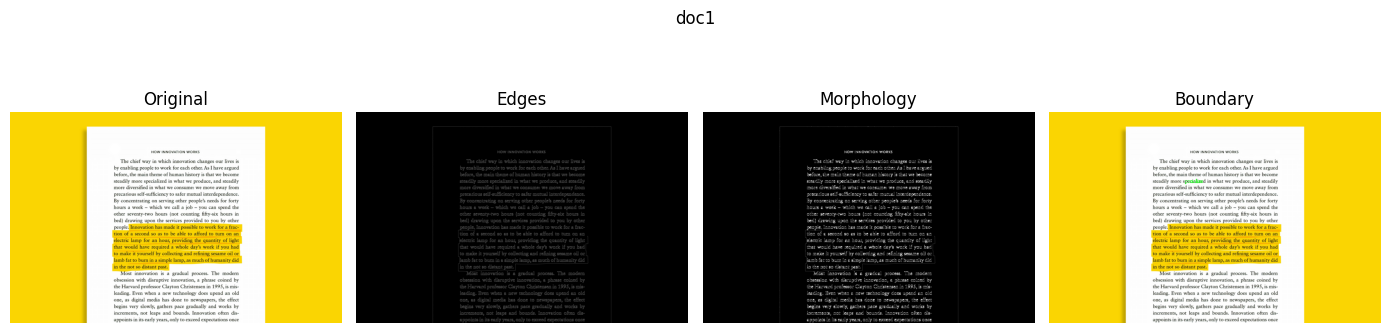

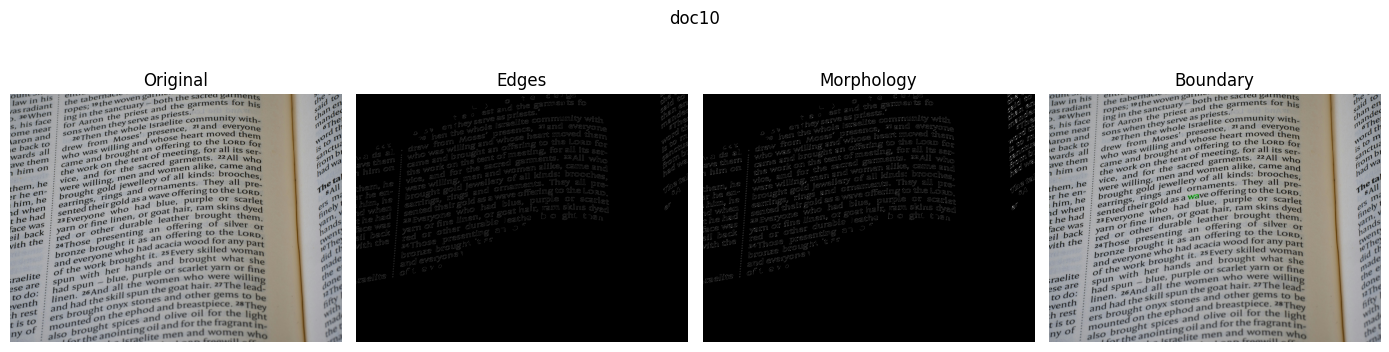

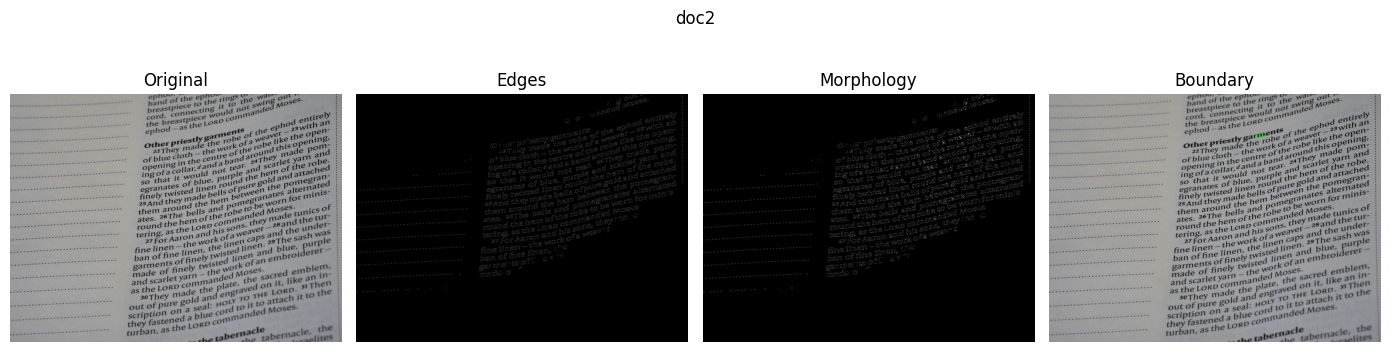

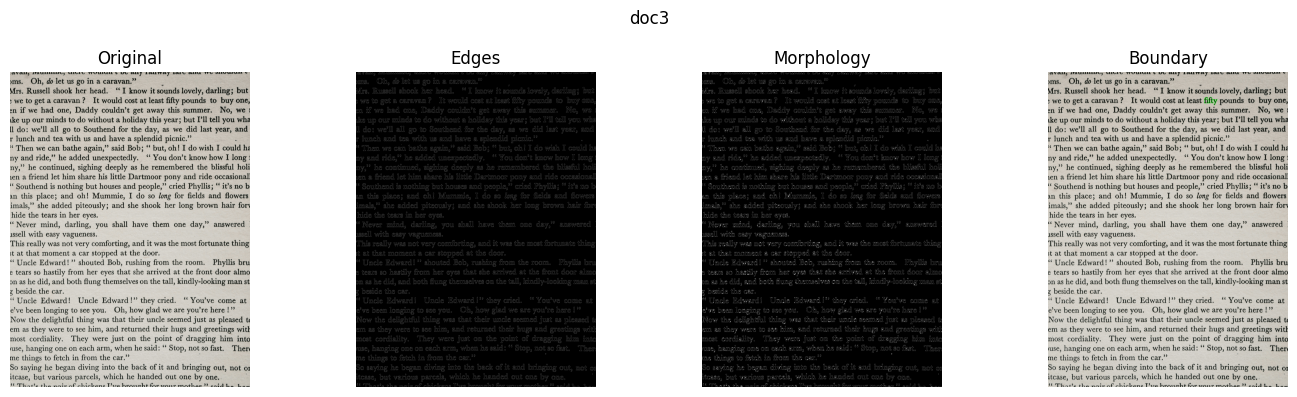

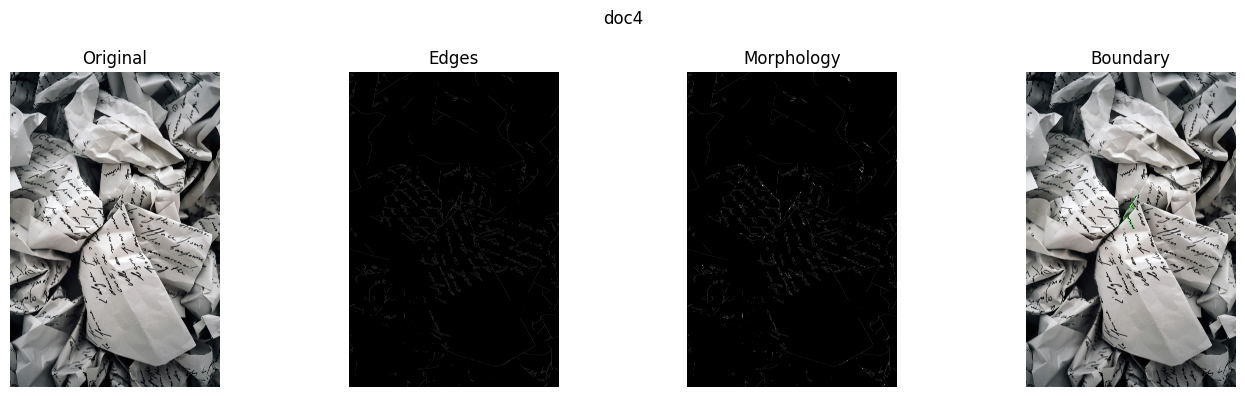

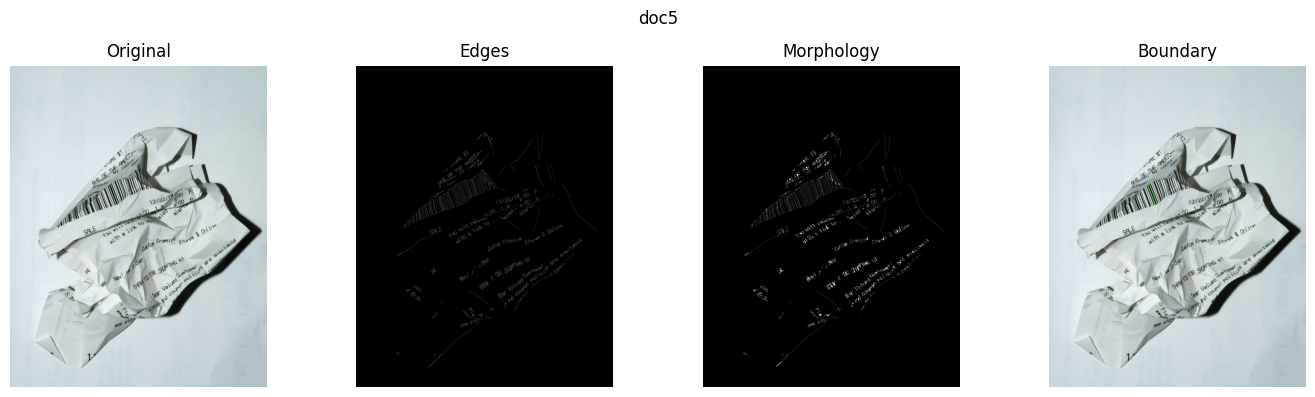

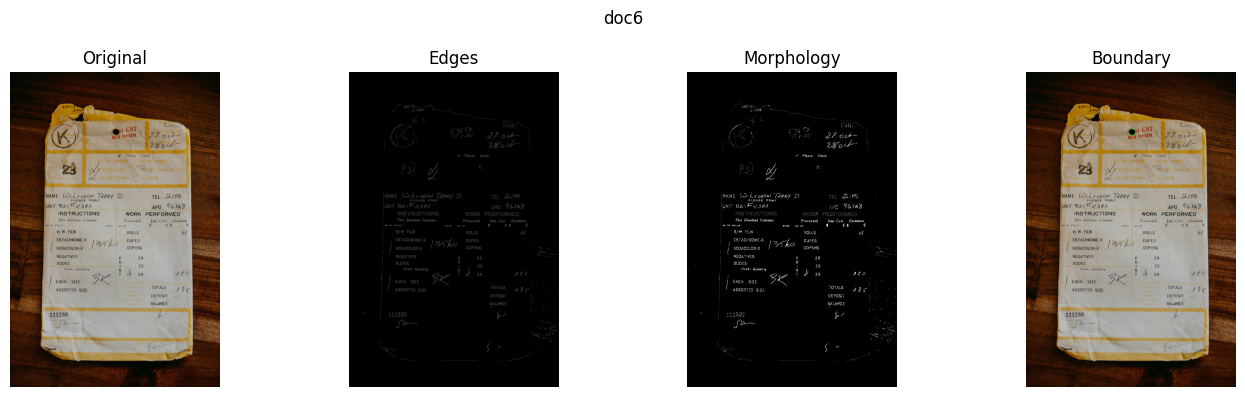

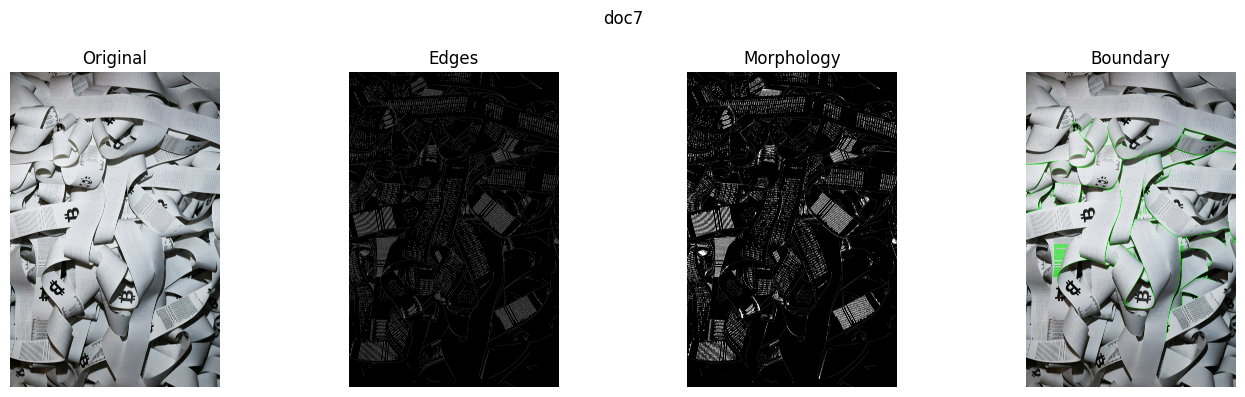

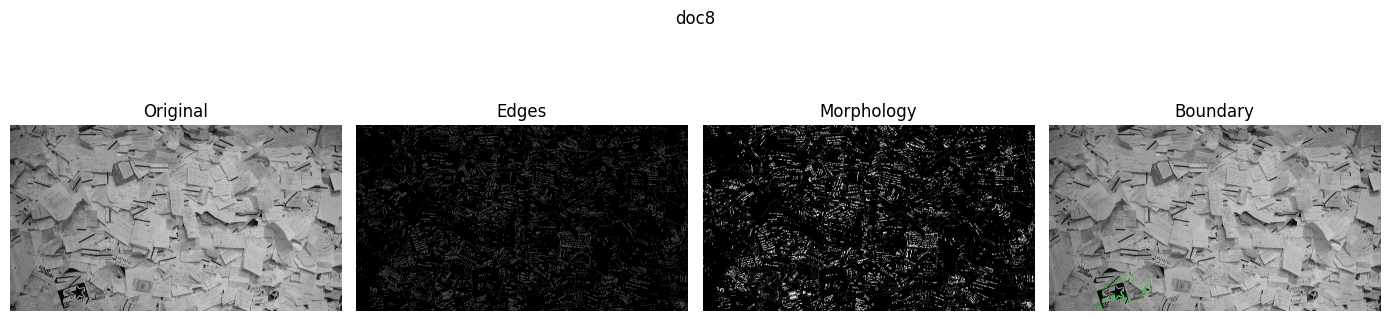

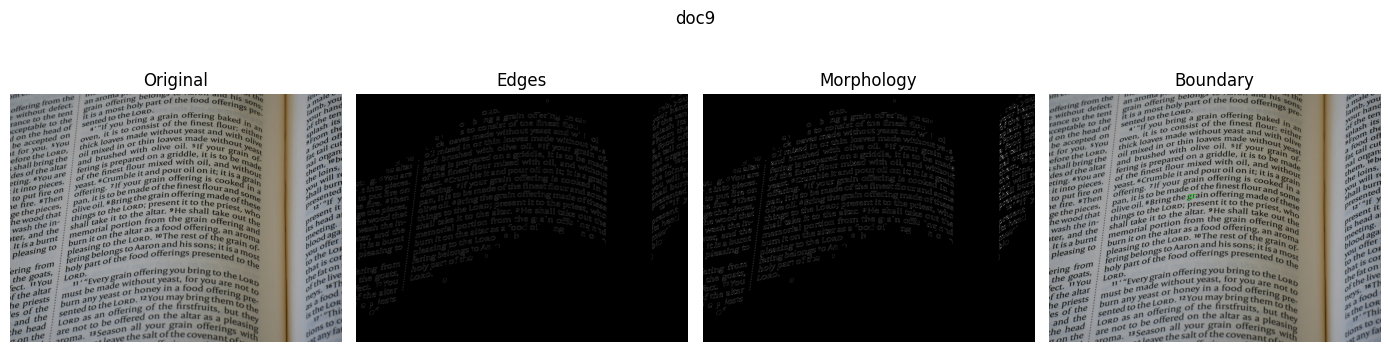

In [7]:
files = sorted(os.listdir("documents"))

for filename in files:

    name = os.path.splitext(filename)[0]

    original = cv2.imread(f"output/{name}_original.jpg")
    edges = cv2.imread(f"output/{name}_edges.jpg", 0)
    morph = cv2.imread(f"output/{name}_morphology.jpg", 0)
    boundary = cv2.imread(f"output/{name}_boundary.jpg")

    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    boundary = cv2.cvtColor(boundary, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14,4))

    plt.subplot(1,4,1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(edges, cmap="gray")
    plt.title("Edges")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(morph, cmap="gray")
    plt.title("Morphology")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(boundary)
    plt.title("Boundary")
    plt.axis("off")

    plt.suptitle(name)

    plt.tight_layout()
    plt.show()